## Exploratory data analysis(EDA) and data wrangling using Pandas library on plasmodium vivax simulated datasets
In machine learning workflows, raw data are rarely in a form that is immediately suitable for model development. Although the present dataset is synthetically generated and structured according to predefined evolutionary scenarios (A–E), it still requires systematic exploration to ensure its suitability for downstream analysis.

Exploratory Data Analysis (EDA) serves as a critical preliminary step in this process, enabling a comprehensive understanding of the dataset’s structure, feature behaviour, and overall quality. This includes examining the distribution of summary statistics, identifying potential anomalies or outliers, and assessing the presence of missing or inconsistent values that may require imputation or preprocessing.

Furthermore, particular attention must be given to the balance of class labels across the different evolutionary scenarios. Class imbalance can introduce bias into model training, leading to inflated performance metrics and poor generalisation. Therefore, evaluating class distribution is essential to ensure that subsequent predictive models are both robust and reliable.

Overall, rigorous EDA not only enhances data quality but also informs the selection of appropriate preprocessing strategies and modelling approaches, thereby maximising the predictive performance and interpretability of the final model.

load modules 
1.Below are included all the relevant libriries used in the pipeline.


In [ ]:
#Data visualisation 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from mpl_toolkits.mplot3d import Axes3D

#sklearn module
from sklearn.preprocessing import StandardScaler, LabelEncoder
#PCA
from sklearn.decomposition import PCA
#TSNE
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, cross_val_score,validation_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,classification_report,roc_auc_score,ConfusionMatrixDisplay,confusion_matrix,)
from sklearn import metrics, tree
#Umap
import umap
#Pythorch
import torch
import torch.nn as nn
import torch.optim as optim



2.Load datasets.
Each dataset corresponds to a different demographic model (E–I)
concatenate all datasets vertically (row-wise).After combining, we reset the index so it runs from 0 → n.

In [132]:
files = ["E", "F", "G", "H", "I"]

dfs = []

for name in files:
    df = pd.read_csv(f"~/downloads/simulation_summary_stats{name}.tsv", sep="\t")
    df["dataset"] = name  
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=False)
print(combined_df.head(5))

     pi_col   pi_ebro  Tajimas_col  Tajimas_ebro  Segregating_sites_col  \
0  0.001919  0.000711     1.177224      0.014992                  0.006   
1  0.002251  0.002311    -0.392490     -1.388181                  0.014   
2  0.002224  0.003911     0.871438     -1.687186                  0.008   
3  0.001763  0.005200    -0.537607     -1.975831                  0.012   
4  0.000158  0.000800    -1.223813     -1.400851                  0.004   

   Segregating_sites_ebro       Fst  Bin_1_col  Bin_5_col  Bin_2_col  \
0                   0.002  0.299548   0.960396   0.039604   0.000000   
1                   0.010  0.167625   0.980198   0.009901   0.000000   
2                   0.018  0.048440   0.990099   0.009901   0.000000   
3                   0.026  0.163236   0.980198   0.009901   0.009901   
4                   0.004  0.001264   0.970297   0.009901   0.000000   

   Bin_3_col  Bin_4_col  Bin_1_ebro  Bin_2_ebro  Bin_5_ebro  Bin_3_ebro  \
0   0.000000   0.000000    0.818182    0.

2.1After the datasets are mergerd,we inspect the dataframe.

In [154]:
print("Combined shape:", combined_df.shape)
print("\nFirst 10 rows:")
print(combined_df.head(5))
print(combined_df["dataset"].count())

Combined shape: (100000, 19)

First 10 rows:
     pi_col   pi_ebro  Tajimas_col  Tajimas_ebro  Segregating_sites_col  \
0  0.001919  0.000711     1.177224      0.014992                  0.006   
1  0.002251  0.002311    -0.392490     -1.388181                  0.014   
2  0.002224  0.003911     0.871438     -1.687186                  0.008   
3  0.001763  0.005200    -0.537607     -1.975831                  0.012   
4  0.000158  0.000800    -1.223813     -1.400851                  0.004   

   Segregating_sites_ebro       Fst  Bin_1_col  Bin_5_col  Bin_2_col  \
0                   0.002  0.299548   0.960396   0.039604   0.000000   
1                   0.010  0.167625   0.980198   0.009901   0.000000   
2                   0.018  0.048440   0.990099   0.009901   0.000000   
3                   0.026  0.163236   0.980198   0.009901   0.009901   
4                   0.004  0.001264   0.970297   0.009901   0.000000   

   Bin_3_col  Bin_4_col  Bin_1_ebro  Bin_2_ebro  Bin_5_ebro  Bin_3_ebro

To prepare the data for modelling, missing values were addressed within the feature matrix. The target column was first removed using X = combined_df.drop(columns=['dataset']), and only numerical features were retained with X = X.select_dtypes(include=["number"]), as median imputation applies to numeric data only.

Missing values were then replaced using X = X.fillna(X.median()), which fills each column’s NaN values with its median. This method is preferred due to its robustness to outliers, making it suitable for biological datasets.

A final check using X.isnull().sum() confirmed that all missing values were successfully imputed.

In [110]:

X = combined_df.drop(columns=['dataset'])
X = X.select_dtypes(include=["number"])
X = X.fillna(X.median())
missing = X.isnull().sum()

print(missing)

pi_col                    0
pi_ebro                   0
Tajimas_col               0
Tajimas_ebro              0
Segregating_sites_col     0
Segregating_sites_ebro    0
Fst                       0
Bin_1_col                 0
Bin_5_col                 0
Bin_2_col                 0
Bin_3_col                 0
Bin_4_col                 0
Bin_1_ebro                0
Bin_2_ebro                0
Bin_5_ebro                0
Bin_3_ebro                0
Bin_4_ebro                0
dtype: int64


now i decode the categorical labels in the dataset column 


In [149]:
#for the dataset column take the label and buikd a dictionary label is the key and value is the number 


dictionary={"E":0,"F":1,"G":2,"H":3,"I":4}
combined_df['dataset_encoded'] = combined_df['dataset'].map(dictionary)
print(combined_df.head(5))
combined_df.shape
y=combined_df['dataset_encoded']
y.shape






      

     pi_col   pi_ebro  Tajimas_col  Tajimas_ebro  Segregating_sites_col  \
0  0.001919  0.000711     1.177224      0.014992                  0.006   
1  0.002251  0.002311    -0.392490     -1.388181                  0.014   
2  0.002224  0.003911     0.871438     -1.687186                  0.008   
3  0.001763  0.005200    -0.537607     -1.975831                  0.012   
4  0.000158  0.000800    -1.223813     -1.400851                  0.004   

   Segregating_sites_ebro       Fst  Bin_1_col  Bin_5_col  Bin_2_col  \
0                   0.002  0.299548   0.960396   0.039604   0.000000   
1                   0.010  0.167625   0.980198   0.009901   0.000000   
2                   0.018  0.048440   0.990099   0.009901   0.000000   
3                   0.026  0.163236   0.980198   0.009901   0.009901   
4                   0.004  0.001264   0.970297   0.009901   0.000000   

   Bin_3_col  Bin_4_col  Bin_1_ebro  Bin_2_ebro  Bin_5_ebro  Bin_3_ebro  \
0   0.000000   0.000000    0.818182    0.

(100000,)

6.Scale features

StandardScaler transforms data so that: - mean = 0and - standard deviation = 1.This ensures all features contribute equally to models.
Most importantly the dataframe is converted into numerical features,so that the machine learning algorithm can perform their tasks

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(100000, 17)


7.In this section, three dimensionality reduction techniques are employed to investigate the underlying structure of the dataset and to facilitate the identification of latent patterns and clustering behaviour. These methods include Principal Component Analysis (PCA), t-distributed Stochastic Neighbor Embedding (t-SNE), and Uniform Manifold Approximation and Projection (UMAP), each of which operates under different mathematical assumptions and offers distinct advantages for data exploration.

to constract the PCA I use 3 number of components `pca = PCA(n_components=3)`

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

combined_df['pca-one'] = pca_result[:, 0]
combined_df['pca-two'] = pca_result[:, 1]
combined_df['pca-three'] = pca_result[:, 2]

#TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=500)

X_tsne = tsne.fit_transform(X_scaled)


combined_df['tsne1'] = X_tsne[:, 0]
combined_df['tsne2'] = X_tsne[:, 1]



#Apply UMAP
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)


combined_df['umap1'] = X_umap[:, 0]
combined_df['umap2'] = X_umap[:, 1]
combined_df['umap3'] = X_umap[:, 2]




o explore the structure of the dataset, three dimensionality reduction techniques—PCA, t-SNE, and UMAP—were visualised using 2D scatter plots. These methods provide complementary perspectives on the data, allowing both global variance (PCA) and local structure (t-SNE, UMAP) to be assessed.

A 2×2 subplot layout was created using fig, axes = plt.subplots(2, 2, figsize=(14, 10)), enabling all visualisations to be displayed within a single figure for direct comparison. Seaborn’s scatterplot function was used for all plots to ensure consistent styling and automatic grouping via hue='dataset'.

The PCA projection was plotted using sns.scatterplot(data=combined_df, x='pca-one', y='pca-two', hue='dataset', ax=axes[0, 0], alpha=0.4, s=20, linewidth=0). The axes were labelled with the percentage of variance explained using pca.explained_variance_ratio_, providing insight into how much information is retained in each principal component. This plot captures the global variance structure of the dataset.

The t-SNE projection was generated with sns.scatterplot(data=combined_df, x='tsne1', y='tsne2', hue='dataset', ax=axes[0, 1], alpha=0.4, s=20, linewidth=0, legend=False). t-SNE emphasises local relationships between samples, making it particularly useful for identifying clusters and nonlinear patterns.

Similarly, the UMAP projection was visualised using sns.scatterplot(data=combined_df, x='umap1', y='umap2', ax=axes[1, 0], alpha=0.4, s=20, linewidth=0, legend=False). UMAP preserves both local and some global structure, often producing clearer cluster separation compared to t-SNE.

To improve readability, marker size (s=20) and transparency (alpha=0.4) were adjusted to reduce overplotting, while linewidth=0 removed marker edges for a cleaner appearance. The legend was displayed only once and positioned outside the main plot area using axes[0, 0].legend(..., bbox_to_anchor=(1.05, 1)) to avoid clutter. The final subplot was unused and hidden via axes[1, 1].axis('off').

This combined visualisation enables efficient comparison of dimensionality reduction methods, highlighting differences in how each technique represents the underlying structure of the data.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

#PCA plot
sns.set(style="whitegrid")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PCA 
sns.scatterplot(data=combined_df,x='pca-one',y='pca-two',hue='dataset',ax=axes[0, 0],alpha=0.4,s=20,linewidth=0)

axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0, 0].set_title('PCA')

#t-SNE plot
sns.scatterplot(data=combined_df,x='tsne1',y='tsne2',hue='dataset',ax=axes[0, 1],alpha=0.4,s=20,linewidth=0,legend=False)

axes[0, 1].set_title('t-SNE')

# UMAP plot
sns.scatterplot(data=combined_df, x='umap1',y='umap2',ax=axes[1, 0],alpha=0.4,s=20,linewidth=0,legend=False)

axes[1, 0].set_title('UMAP')

axes[1, 1].axis('off') #to hide empty fig 

#legends here are moved outside
axes[0, 0].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

PCA plot using plotly 

In [ ]:
#plot with plotly 
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser" #force plotly to open in browser

new_data = pd.concat(
    [combined_df['pca-one'], combined_df['pca-two'], combined_df['pca-three'], combined_df['dataset_encoded']],
    axis=1
)
fig = px.scatter_3d(new_data,
    x='pca-one',
    y='pca-two',
    z='pca-three',
    color='dataset_encoded',
    title='3D PCA Plot',
    labels={
        'pca-one': f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        'pca-two': f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        'pca-three': f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)'
    }
)

fig.show()

Decision Tree Visualisation

To improve interpretability, the decision tree was visualised using a reduced depth. Full trees can become overly complex, so max_depth=3 was applied in plot_tree to display only the most important splits.

The plot was generated using `plot_tree(model_one, feature_names=X.columns, class_names=[...], filled=True, rounded=True)`, where `filled=True` highlights class predictions and rounded=True improves readability. Feature names were included to show which variables drive each split.

This simplified visualisation focuses on the key decision rules, making it easier to understand how the model separates classes while avoiding clutter from deeper branches.

Decision tree model accuracy: 0.9143
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      4018
           1       0.93      0.91      0.92      4015
           2       0.90      0.91      0.91      4002
           3       0.95      0.94      0.95      3987
           4       0.87      0.87      0.87      3978

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000

Accuracy for random forest : 0.9418
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4018
           1       0.95      0.94      0.94      4015
           2       0.93      0.95      0.94      4002
           3       0.97      0.97      0.97      3987
           4       0.92      0.91      0.92      3978

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weig

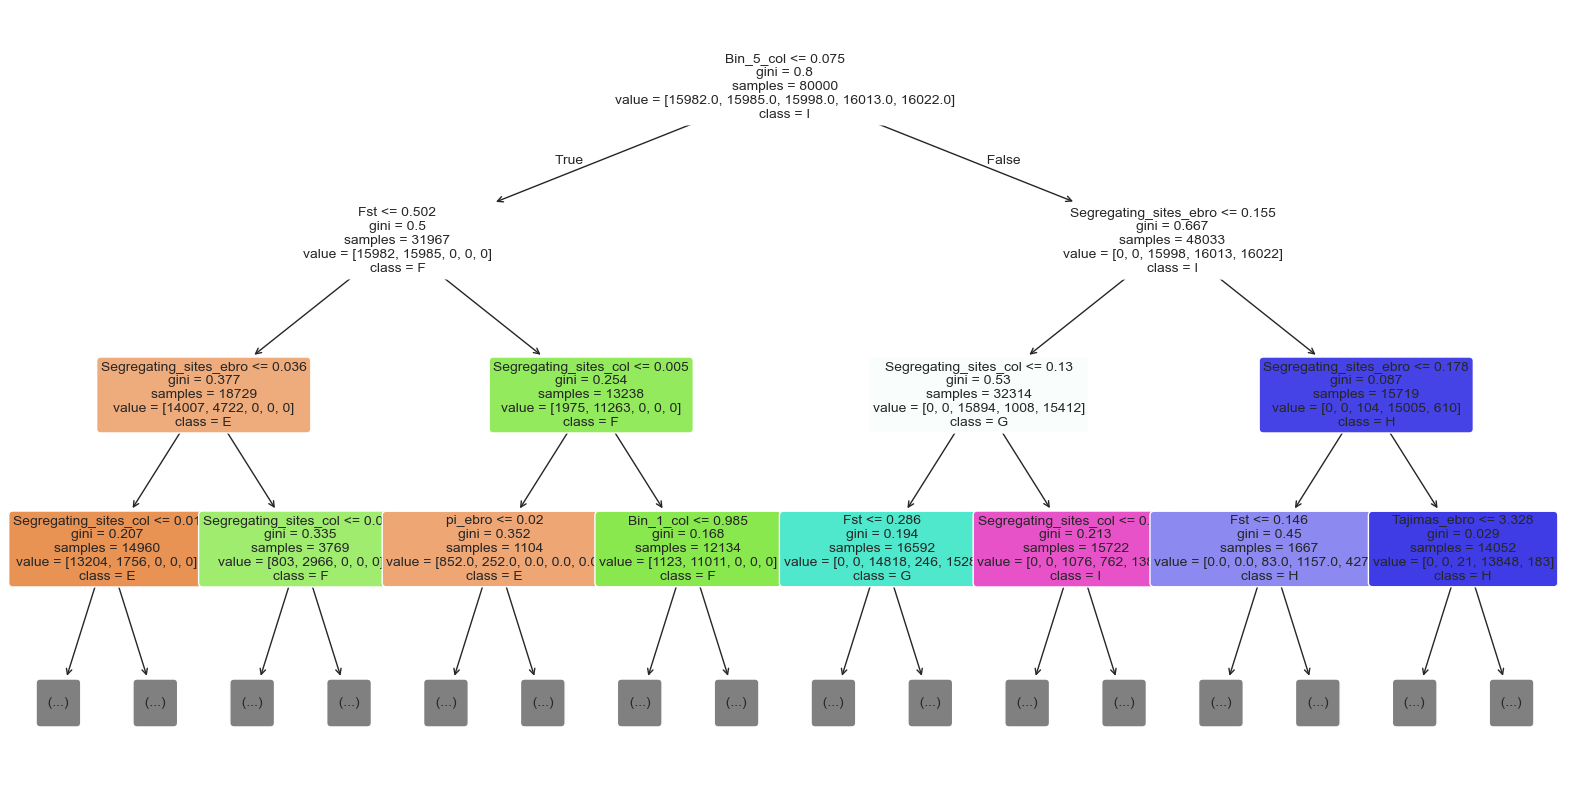

In [188]:

#MACHINE LEARNING PIPELINE


# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Decision Three 
dec_tree_class=tree.DecisionTreeClassifier()
dec_tree_class=dec_tree_class.fit(X_train,y_train)
y_pred_t=dec_tree_class.predict(X_test)
print("Decision tree model accuracy:", accuracy_score(y_test, y_pred_t))
print(classification_report(y_test, y_pred_t))


#Random forest 
random_f=RandomForestClassifier(random_state=42)
random_f.fit(X_train, y_train)
y_pred_rf = random_f.predict(X_test)
print("Accuracy for random forest :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

#SVM 
svm_model =SVC(random_state=42)
svm_model.fit(X_train, y_train)#train
y_pred_svm = svm_model.predict(X_test) #prediction
print("Support vector machine accuracy", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(20,10))
plot_tree(dec_tree_class,feature_names=X.columns,class_names=["E", "F", "G", "H", "I"],filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10)

plt.show()



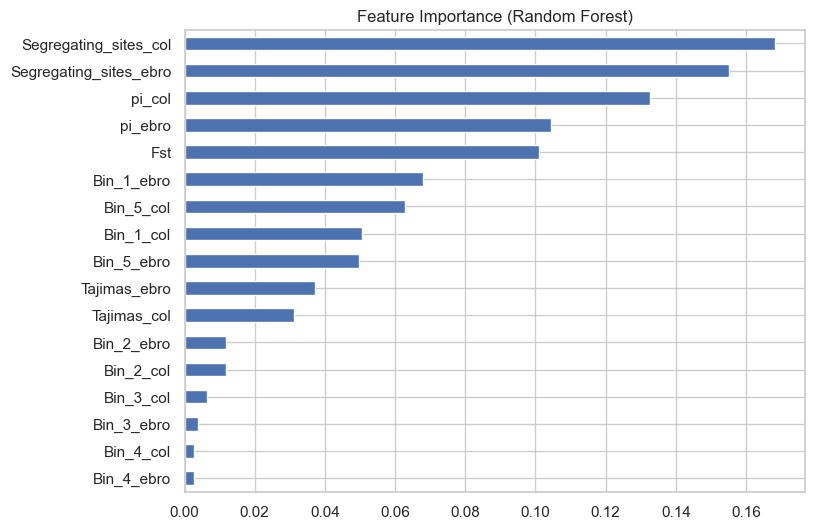

In [ ]:
#feature importance for Random forest

importance = random_f.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Random Forest)")
plt.show()

SVM DECISION BOUNDARY PCA PLOT

/opt/anaconda3/envs/pvivax_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


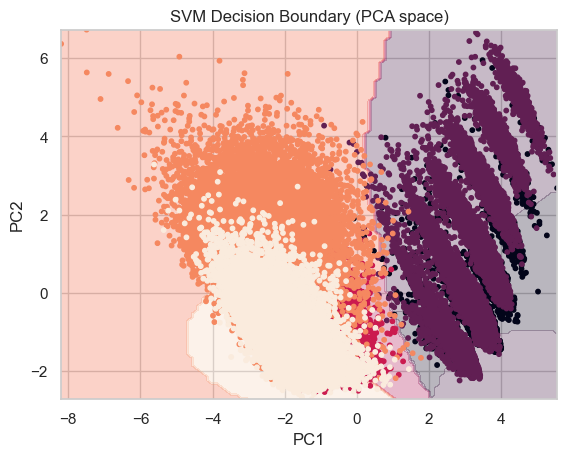

In [192]:
import numpy as np
import matplotlib.pyplot as plt

# Use 2D data (e.g. PCA)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

combined_df['pca-one'] = pca_result[:, 0]
combined_df['pca-two'] = pca_result[:, 1]

X_plot = combined_df[['pca-one', 'pca-two']]
y_plot = y

# Train SVM on 2D data
from sklearn.svm import SVC
model_2d = SVC(kernel='rbf')
model_2d.fit(X_plot, y_plot)

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X_plot.iloc[:,0].min(), X_plot.iloc[:,0].max(), 100),
    np.linspace(X_plot.iloc[:,1].min(), X_plot.iloc[:,1].max(), 100)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_plot.iloc[:,0], X_plot.iloc[:,1], c=y_plot, s=10)

plt.title("SVM Decision Boundary (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Plots of the tree model confusion matrix 


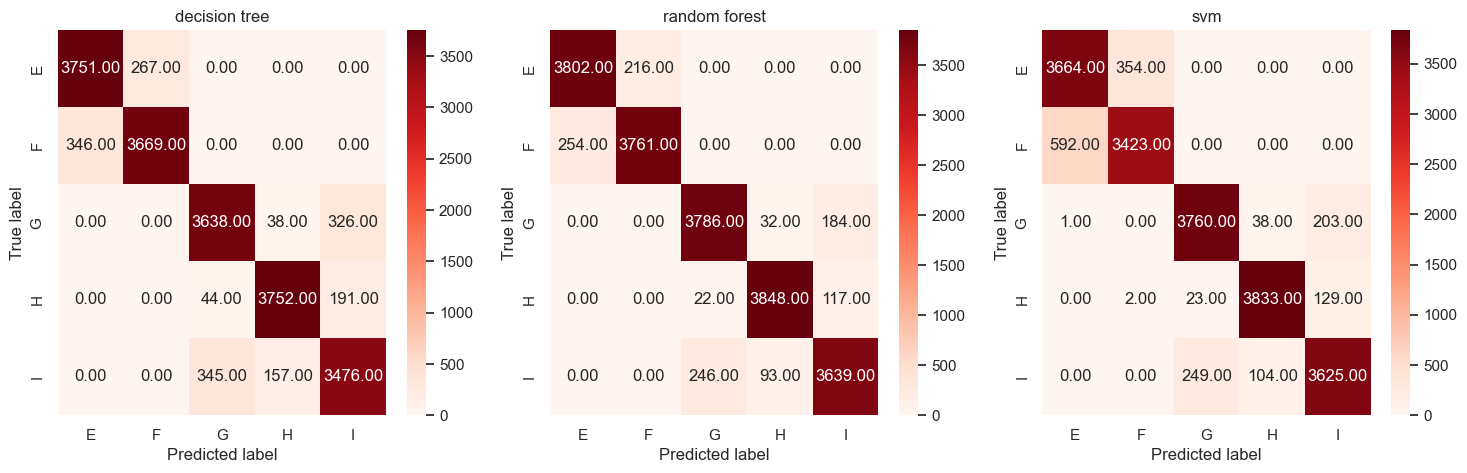

In [ ]:
cf_1=confusion_matrix(y_test, y_pred_t)
cf_2=confusion_matrix(y_test, y_pred_rf)
cf_3=confusion_matrix(y_test, y_pred_svm)


#Decision tree confusion matrix
sns.set(style="whitegrid")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["E", "F", "G", "H", "I"]
predictions=[cf_1,cf_2,cf_3]
titles= ["decision tree","random forest","svm"]

for ax, cm, title in zip(axes, predictions, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Reds',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)


plt.show()
    



In [ ]:
#create a costum dataset for pytorch
from torch.utils.data import Dataset
import torch

class TabularDataset(Dataset):
    def __init__(self, df_combined):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
        

    def __getitem__(self, idx):
        X = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx],dtype=torch.long)

        return X, y
    
    Dataset[0]



In [ ]:
#split dataset into training and test batches 

from torch.utils.data import DataLoader


train, test = train_test_split(combined_df, test_size=0.2, random_state=42)

train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

train_dataset = TabularDataset(train)
test_dataset = TabularDataset(test)



print("Features:", X)
print("Label:", y) #this tensor belong to class 3


from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


#inspecting one batch 







#here I inspect one batch for the training
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    print(y_batch[:5])
    break
#optimizer
#takes the error (loss) and adjusts the model parameters to reduce that error.




DEFINE THE MODEL IS THE NEXT STEP 